In [39]:
import pandas as pd

In [40]:
import seaborn as sns

In [41]:
df=sns.load_dataset("titanic")
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


<Axes: xlabel='survived'>

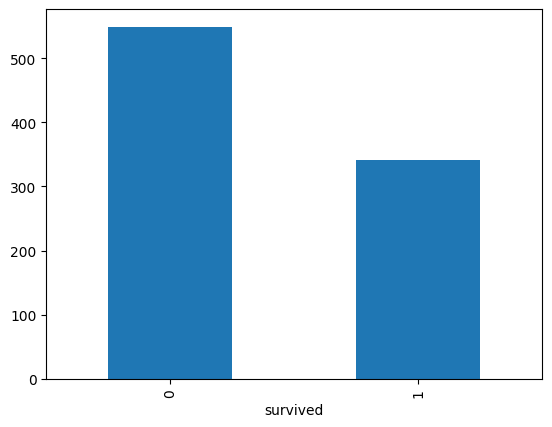

In [42]:
df["survived"].value_counts().plot(kind="bar")

In [43]:
df.groupby(["survived","sex"])["survived"].count()

survived  sex   
0         female     81
          male      468
1         female    233
          male      109
Name: survived, dtype: int64

In [44]:
df.isna().sum()

,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


In [45]:
df=df.drop(["deck","embark_town","embarked"],axis=1)

In [46]:
df1=df["age"].mean()

In [47]:
df["age"]=df["age"].fillna(df1)

In [48]:
df.isna().sum()

,0
survived,0
pclass,0
sex,0
age,0
sibsp,0
parch,0
fare,0
class,0
who,0
adult_male,0


In [49]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,class,who,adult_male,alive,alone
0,0,3,male,22.0,1,0,7.2500,Third,man,True,no,False
1,1,1,female,38.0,1,0,71.2833,First,woman,False,yes,False
2,1,3,female,26.0,0,0,7.9250,Third,woman,False,yes,True
3,1,1,female,35.0,1,0,53.1000,First,woman,False,yes,False
4,0,3,male,35.0,0,0,8.0500,Third,man,True,no,True


In [50]:
y=df[["survived"]]
x=df.drop(["survived"],axis=1)

In [51]:
x.head()

,pclass,sex,age,sibsp,parch,fare,class,who,adult_male,alive,alone
0,3,male,22.0,1,0,7.2500,Third,man,True,no,False
1,1,female,38.0,1,0,71.2833,First,woman,False,yes,False
2,3,female,26.0,0,0,7.9250,Third,woman,False,yes,True
3,1,female,35.0,1,0,53.1000,First,woman,False,yes,False
4,3,male,35.0,0,0,8.0500,Third,man,True,no,True


In [52]:
from sklearn.preprocessing  import LabelEncoder,MinMaxScaler
le=LabelEncoder()
ms=MinMaxScaler()
from pandas.api.types import is_numeric_dtype

In [53]:
for col in x.columns:
  if is_numeric_dtype(x[col]):
    x[col]=ms.fit_transform(x[[col]])
  else:
    x[col]=le.fit_transform(x[col])



In [54]:
x.head()

,pclass,sex,age,sibsp,parch,fare,class,who,adult_male,alive,alone
0,1.0,1,0.271174,0.125,0.0,0.014151,2,1,1.0,0,0.0
1,0.0,0,0.472229,0.125,0.0,0.139136,0,2,0.0,1,0.0
2,1.0,0,0.321438,0.000,0.0,0.015469,2,2,0.0,1,1.0
3,0.0,0,0.434531,0.125,0.0,0.103644,0,2,0.0,1,0.0
4,1.0,1,0.434531,0.000,0.0,0.015713,2,1,1.0,0,1.0


In [55]:
from sklearn.model_selection import train_test_split
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=.2,random_state=43)

In [75]:
from sklearn.neighbors import KNeighborsClassifier,KNeighborsRegressor
knc=KNeighborsClassifier()

In [57]:
model =knc.fit(xtrain,ytrain)

/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


In [58]:
model.score(xtrain,ytrain)

0.9901685393258427

In [59]:
model.score(xtest,ytest)

0.9832402234636871

In [62]:
pred=model.predict(xtest)

In [64]:
#evaluate the model
from sklearn.metrics import confusion_matrix,classification_report,accuracy_score


In [66]:
#confussion matrix
cm=confusion_matrix(pred,ytest)

In [68]:
cm

array([[107,   0],
       [  3,  69]])

<Axes: >

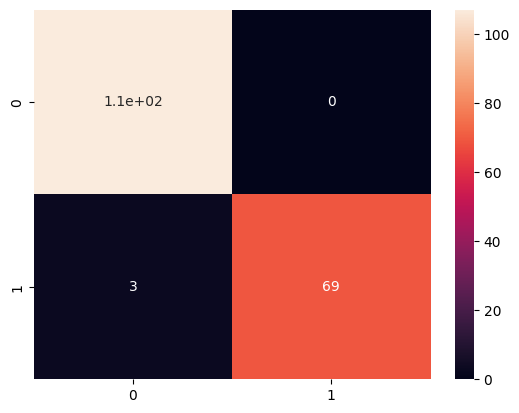

In [69]:
sns.heatmap(cm,annot=True)

In [70]:
ytest.value_counts()

,count
survived,
0,110
1,69


In [72]:
cr=classification_report(pred,ytest)
print(cr)

              precision    recall  f1-score   support

           0       0.97      1.00      0.99       107
           1       1.00      0.96      0.98        72

    accuracy                           0.98       179
   macro avg       0.99      0.98      0.98       179
weighted avg       0.98      0.98      0.98       179



In [81]:
#check  the best k
for i in range(3,20):
  print("value of k is",i)
  knn1=KNeighborsClassifier(n_neighbors=i)
  model1=knn1.fit(xtrain,ytrain)
  print("check the train score")
  print(model1.score(xtrain,ytrain))
  print("check the test score")
  print(model1.score(xtest,ytest))
  print("--------------------->")
  pred=model1.predict(xtest)
  print("evaluate the model")
  cm=confusion_matrix(pred,ytest)
  print(cm)




value of k is 3
check the train score
0.9943820224719101
check the test score
0.994413407821229
--------------------->
evaluate the model
[[109   0]
 [  1  69]]
value of k is 4
check the train score
0.9957865168539326
check the test score
0.994413407821229
--------------------->
evaluate the model
[[109   0]
 [  1  69]]
value of k is 5
check the train score
0.9901685393258427
check the test score
0.9832402234636871
--------------------->
evaluate the model
[[107   0]
 [  3  69]]
value of k is 6


/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for 

check the train score
0.9901685393258427
check the test score
0.9832402234636871
--------------------->
evaluate the model
[[107   0]
 [  3  69]]
value of k is 7
check the train score
0.9901685393258427
check the test score
0.9832402234636871
--------------------->
evaluate the model
[[107   0]
 [  3  69]]
value of k is 8
check the train score
0.9901685393258427
check the test score
0.9832402234636871
--------------------->
evaluate the model
[[107   0]
 [  3  69]]
value of k is 9


/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for 

check the train score
0.9901685393258427
check the test score
0.9832402234636871
--------------------->
evaluate the model
[[107   0]
 [  3  69]]
value of k is 10
check the train score
0.976123595505618
check the test score
0.9664804469273743
--------------------->
evaluate the model
[[107   3]
 [  3  66]]
value of k is 11
check the train score
0.976123595505618
check the test score
0.9664804469273743
--------------------->
evaluate the model
[[107   3]
 [  3  66]]
value of k is 12
check the train score
0.976123595505618
check the test score


/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


0.9608938547486033
--------------------->
evaluate the model
[[107   4]
 [  3  65]]
value of k is 13
check the train score
0.976123595505618
check the test score
0.9608938547486033
--------------------->
evaluate the model
[[107   4]
 [  3  65]]
value of k is 14
check the train score
0.976123595505618
check the test score
0.9608938547486033
--------------------->
evaluate the model
[[107   4]
 [  3  65]]
value of k is 15
check the train score
0.976123595505618
check the test score
0.9608938547486033
--------------------->
evaluate the model
[[107   4]
 [  3  65]]
value of k is 16


/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for 

check the train score
0.976123595505618
check the test score
0.9608938547486033
--------------------->
evaluate the model
[[107   4]
 [  3  65]]
value of k is 17
check the train score
0.976123595505618
check the test score
0.9608938547486033
--------------------->
evaluate the model
[[107   4]
 [  3  65]]
value of k is 18
check the train score
0.976123595505618
check the test score
0.9608938547486033
--------------------->
evaluate the model
[[107   4]
 [  3  65]]
value of k is 19
check the train score
0.976123595505618
check the test score
0.9608938547486033
--------------------->
evaluate the model
[[107   4]
 [  3  65]]


/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
